# Limit Order Multiple Assets DEX

The purpose of this Notebook is to demonstrate the use of Settlement Networks as a viechle to deliver a business solution.
The question is wether it is possible to create a multiple assets DEX without liquidity pool.
There are no investors into the liquidity.
There is an escrow forall assets sold.
Seller is free to commit to settle with wathewer he wants.
All settlements are made in the settlement unit of account (UOA).
For the purpose of this example the UOA is $ and all assets exchanged are crypto assets.
This would allow for DEX to function without the involvement of third party liquidity providers.
We are building a network that does a function of a multiple assets DEX by matching limit orders expressed as obligations and commitments.
We use the [Multilateral Settlement Network](docs/Multilateral_Settlement_Network.md) model and notation.

## Overview

### Situation

We have Alice, Bob, Charlie, and Dana. They all participate in a settlement network that uses USD as UOA.
* Alice escrowed ATOMs (5.0)
* Bob escrowed TIA (4.5)
* Charlie escroved OSMO (0.4)
* Dana escrowed INJ (17.5)

This network might have many other participants denoted by N.

Alice wants to sell 100 USD worth of ATOM and buy 100 USD worth of TIA.
Bob wants to sell 100 USD worth of TIA and buy 100 USD worth of OSMO.
Charlie wants to sell 100 USD worth of OSMO and buy 100 USD worth of INJ.
Dana wants to sell 100 USD worth of INJ and buy 100 USD worth of ATOM.

They don't know each other and have no clue of each other intentions. But they all sell at low tick price and buy at high tick price

### Problem

* Constructing a UOA flow that satisfies the Alice, Bob, Charlie, and Dana intents.
* Final settlement of UOA settlement flow with redistribution of all assets within the escrow.

### Solution

* Introduce a Limit-Order-DEX nodes to connect the trading intents of the parties involved.
* Use the spread among trading prices to incentivise all participants for further use of Limit-Order-DEX.
* Communicate the Volume Weighted Average Price (VWAP) to create the excitement for new arbitrage opportunities with Crypto.

## Preparing the environment

### Input data

The data describing this situation among Alice, Bob and Charlie in more detail is available [here](data/limit_order_multi_DEX.csv)

### Import the functions for modeling

We import the functions required to model the settlement networks.

In [47]:
from utils.graph_operations import *
from utils.graph_visualization import graph_print, graph_draw
from utils.graph_max_flow_solvers import max_flow_solver
from utils.graph_read_write import read_graph_from_csv, split_graph_by_edge_data
import networkx as nx

### Reading the network edges data and setting the presentation of data

We start by reading the data and setting up the parameters for network visualisation. The data represents the payment network $p$.

In [48]:
g = read_graph_from_csv("data/limit_order_multi_DEX.csv")
p = g.copy()
g, g_overline = split_graph_by_edge_data(g, "o/c", "o")

# Define fixed positions of nodes for network graphs
pos = {'Alice':   (3,3),
       'Bob':     (3,1),
       'Charlie': (1,1),
       'Dana':    (1,3),
       '4.9':     (3,4),
       '5.0':     (2,4),
       '5.1':     (1,4),
       '4.4':     (4,1),
       '4.5':     (4,2),
       '4.6':     (4,3),
       '0.45':    (3,0),
       '0.40':    (2,0),
       '0.35':    (1,0),
       '17.6':    (0,1),
       '17.5':    (0,2),
       '17.4':    (0,3),
       'N':       (2,2)}

# Define the labels for the edges of limit order DEX network.
update_edge_labels = {('4.9','Alice'): '100@4.9',
                      ('4.4','Bob'): '100@4.4',
                      ('0.35','Charlie'): '100@0.35',
                      ('17.4','Dana'): '100@17.4',
                      ('Alice','4.6'): '100@4.6',
                      ('Bob','0.45'): '100@0.45',
                      ('Charlie','17.6'): '100@17.6',
                      ('Dana','5.1'): '100@5.1',
                      ('5.0','4.9'): '∞',
                      ('5.1','5.0'): '∞',
                      ('4.5','4.4'): '∞',
                      ('4.6','4.5'): '∞',
                      ('0.40','0.35'): '∞',
                      ('0.45','0.40'): '∞',
                      ('17.5','17.4'): '∞',
                      ('17.6','17.5'): '∞'}

We also need to initialise the DEX contracts for all assets involved and clearly identify traders.

In [49]:
traders = ['Alice', 'Bob', 'Charlie', 'Dana']

assets = ['ATOM', 'TIA', 'OSMO', 'INJ']
ticks = {'ATOM': ['4.9', '5.0', '5.1' ],
         'TIA':  ['4.4', '4.5', '4.6' ],
         'OSMO': ['0.35','0.40','0.45'],
         'INJ':  ['17.4','17.5','17.6']}

escrow = {}
for asset in assets:
    escrow[asset] = {}
    for trader in traders:
        escrow[asset][trader] = sum(g_overline[tick][trader]['capacity'] / float(tick) for tick, trader in g_overline.in_edges(trader) if tick in ticks[asset])
    print(f'Escrow: {asset} : {escrow[asset]}')


Escrow: ATOM : {'Alice': 20.408163265306122, 'Bob': 0, 'Charlie': 0, 'Dana': 0}
Escrow: TIA : {'Alice': 0, 'Bob': 22.727272727272727, 'Charlie': 0, 'Dana': 0}
Escrow: OSMO : {'Alice': 0, 'Bob': 0, 'Charlie': 285.7142857142857, 'Dana': 0}
Escrow: INJ : {'Alice': 0, 'Bob': 0, 'Charlie': 0, 'Dana': 5.74712643678161}


## Visualising the case

### Limit Order Multiple Assets DEX network (LOMADEX)

The LOMADEX is represented by the price ticks connected with infinite flow edges from highest to lowest tick price.
Individual asset tick ladders are joined to existing settlement network that clears in chosen UOA. A "\$" in our example.

The infinity edges among the tick points are there so that the solver can match
* sellers asks, and
* buyers bids
such that settlement of discovered matches is possible.

What is not shown on the network is the escrow. LOMADEX smart contracts setting up this network should not allow traders to commit to sell 100\$ worth of assets if they doesn't escrow the sufficient amount of assets in the contract.

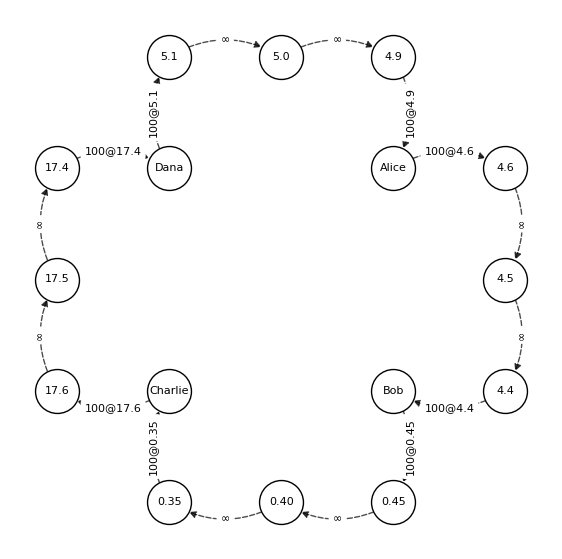

In [50]:
graph_draw(p, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000, update_edge_labels=update_edge_labels, figsize=(7,7))

### Finding a solution to a business problem

Using a solver, we try to find a solution - cyclic structure $\hat{p_b}$ - within the LOMADEX network.
The advantage of the proposed solution is that it does not require a specialised solver. Standard MTCS solver does everything that is required.

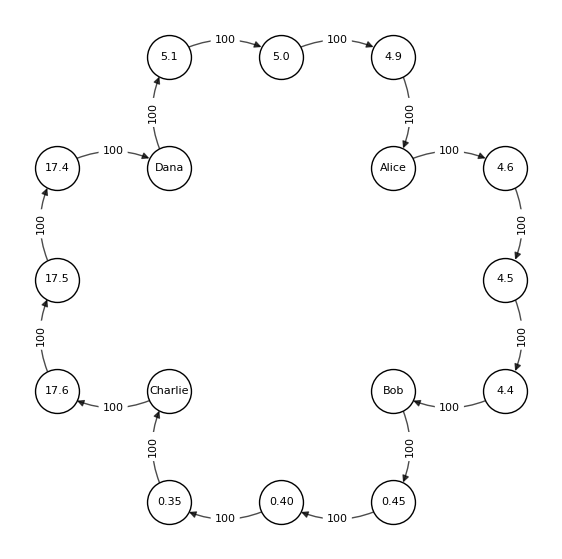

In [51]:
p_hat = max_flow_solver(p)

graph_draw(p_hat, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000, figsize=(7,7))

The business flow traverses both, the obligation and the LOMADEX network.
Business flow has to be a cyclic structure. We can see that each node is perfectly balanced, with amounts coming in, and equal amounts coming out.

Let's see what remains after we settle the business business flow.

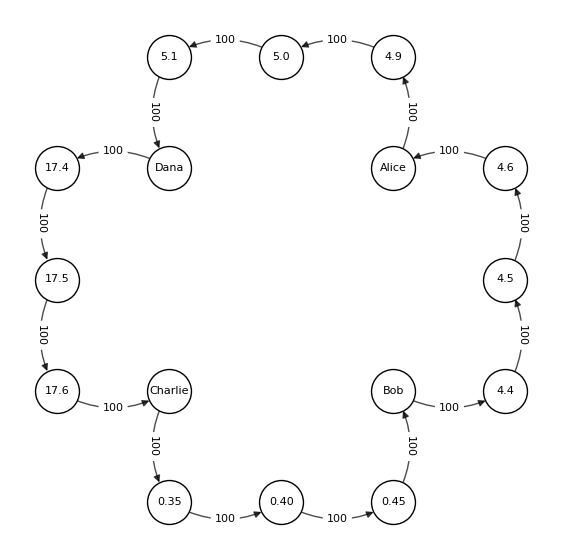

In [52]:
g_prime = +(g-p_hat) + ~(-(g-p_hat))

graph_draw(g_prime, pos=pos, connectionstyle="arc3, rad=0.3", node_size=1000, figsize=(7,7))

At this stage the obligation network is resolved.

As a solver got the asks and bids matching sorted, the LOMADEX contract has to resolve the resulting trades for all assets.

## Distributing the Atom escrow

While the rest of the network is resolved by itself as shown with $g'$, the Atom distribution from the escrow has to be executed within the LODEX contract.

Let's define the required equations to do this.

* $p$ - vector of price ticks in denom/UOA - in our case Atom/USD
* $a$ - vector of asks per price tick
* $b$ - vector of bids per price tick

In [53]:
a = {}
b = {}
p = {}
for asset in assets:
    a[asset] = [sum(g_overline[node][neighbor]['capacity'] for node, neighbor in g_overline.out_edges(node) if neighbor not in ticks[asset]) for node in ticks[asset]]
    b[asset] = [sum(g_overline[neighbor][node]['capacity'] for neighbor, node in g_overline.in_edges(node) if neighbor not in ticks[asset]) for node in ticks[asset]]
    p[asset] = [1/float(tick) for tick in ticks[asset]]

    print(asset)
    print(f'  Price ticks: {p[asset]}')
    print(f'  Asks:        {a[asset]}')
    print(f'  Bids:        {b[asset]}')

ATOM
  Price ticks: [0.2040816326530612, 0.2, 0.19607843137254904]
  Asks:        [100, 0, 0]
  Bids:        [0, 0, 100]
TIA
  Price ticks: [0.22727272727272727, 0.2222222222222222, 0.2173913043478261]
  Asks:        [100, 0, 0]
  Bids:        [0, 0, 100]
OSMO
  Price ticks: [2.857142857142857, 2.5, 2.2222222222222223]
  Asks:        [100, 0, 0]
  Bids:        [0, 0, 100]
INJ
  Price ticks: [0.0574712643678161, 0.05714285714285714, 0.056818181818181816]
  Asks:        [100, 0, 0]
  Bids:        [0, 0, 100]


To redistribute the escrow, we cant use all asks and bids. We need to take only the 
* settled asks $\hat{a}$ and 
* settled bids $\hat{b}$

In [54]:
a_hat = {}
b_hat = {}

for asset in assets:
    a_hat[asset] = [sum(p_hat[node][neighbor]['capacity'] for node, neighbor in p_hat.out_edges(node) if neighbor not in ticks[asset]) for node in ticks[asset]]
    b_hat[asset] = [sum(p_hat[neighbor][node]['capacity'] for neighbor, node in p_hat.in_edges(node) if neighbor not in ticks[asset]) for node in ticks[asset]]

    print(asset)
    print(f'  Settled Asks: {a_hat[asset]}')
    print(f'  Settled Bids: {b_hat[asset]}')

ATOM
  Settled Asks: [100, 0, 0]
  Settled Bids: [0, 0, 100]
TIA
  Settled Asks: [100, 0, 0]
  Settled Bids: [0, 0, 100]
OSMO
  Settled Asks: [100, 0, 0]
  Settled Bids: [0, 0, 100]
INJ
  Settled Asks: [100, 0, 0]
  Settled Bids: [0, 0, 100]


Now we can get the volume of 
* Atoms sold $A = \hat{a} \cdot p$,
* Atoms bought $B = \hat{b} \cdot p$, and
* the spread remaining $S = A - B$

In [55]:
A = {}
B = {}
S = {}

for asset in assets:
    A[asset] = sum(x * y for x, y in zip(a_hat[asset],p[asset]))
    B[asset] = sum(x * y for x, y in zip(b_hat[asset],p[asset]))
    S[asset] = A[asset] - B[asset]

    print(f'{asset} S = A - B : {S[asset]} = {A[asset]} - {B[asset]}')

ATOM S = A - B : 0.8003201280512151 = 20.40816326530612 - 19.607843137254903
TIA S = A - B : 0.9881422924901173 = 22.727272727272727 - 21.73913043478261
OSMO S = A - B : 63.492063492063494 = 285.7142857142857 - 222.22222222222223
INJ S = A - B : 0.06530825496342807 = 5.74712643678161 - 5.681818181818182


We adjust the escrow of traders for their coresponding trades at their limit price ticks.

In [56]:
sales = {}
buys = {}
for asset in assets:
    print(asset)
    print(f'  Initial Escrow: {escrow[asset]}')
    sales[asset] = {}
    buys[asset] = {}
    for trader in traders:
        sales[asset][trader] = sum(p_hat[tick][trader]['capacity'] / float(tick) for tick, trader in p_hat.in_edges(trader) if tick in ticks[asset])
        buys[asset][trader] = sum(p_hat[trader][tick]['capacity'] / float(tick) for trader, tick in p_hat.out_edges(trader) if tick in ticks[asset])
        escrow[asset][trader] = escrow[asset][trader] - sales[asset][trader] + buys[asset][trader]

    print(f'  Sales:          {sales[asset]}')
    print(f'  Buys:           {buys[asset]}')
    print(f'  Trading Escrow: {escrow[asset]}')

ATOM
  Initial Escrow: {'Alice': 20.408163265306122, 'Bob': 0, 'Charlie': 0, 'Dana': 0}
  Sales:          {'Alice': 20.408163265306122, 'Bob': 0, 'Charlie': 0, 'Dana': 0}
  Buys:           {'Alice': 0, 'Bob': 0, 'Charlie': 0, 'Dana': 19.607843137254903}
  Trading Escrow: {'Alice': 0.0, 'Bob': 0, 'Charlie': 0, 'Dana': 19.607843137254903}
TIA
  Initial Escrow: {'Alice': 0, 'Bob': 22.727272727272727, 'Charlie': 0, 'Dana': 0}
  Sales:          {'Alice': 0, 'Bob': 22.727272727272727, 'Charlie': 0, 'Dana': 0}
  Buys:           {'Alice': 21.73913043478261, 'Bob': 0, 'Charlie': 0, 'Dana': 0}
  Trading Escrow: {'Alice': 21.73913043478261, 'Bob': 0.0, 'Charlie': 0, 'Dana': 0}
OSMO
  Initial Escrow: {'Alice': 0, 'Bob': 0, 'Charlie': 285.7142857142857, 'Dana': 0}
  Sales:          {'Alice': 0, 'Bob': 0, 'Charlie': 285.7142857142857, 'Dana': 0}
  Buys:           {'Alice': 0, 'Bob': 222.22222222222223, 'Charlie': 0, 'Dana': 0}
  Trading Escrow: {'Alice': 0, 'Bob': 222.22222222222223, 'Charlie': 0.0,

Then redistribute spread $S$ proportional to the settled amounts.

In [57]:
for asset in assets:
    print(asset)
    print(f'  Trading Escrow: {escrow[asset]}')
    for trader in traders:
        escrow[asset][trader] = escrow[asset][trader] + (S[asset] / (A[asset]+B[asset])) * (sales[asset][trader] + buys[asset][trader])
    print(f'  Final Escrow:   {escrow[asset]}')

ATOM
  Trading Escrow: {'Alice': 0.0, 'Bob': 0, 'Charlie': 0, 'Dana': 19.607843137254903}
  Final Escrow:   {'Alice': 0.40816326530611974, 'Bob': 0.0, 'Charlie': 0.0, 'Dana': 20.0}
TIA
  Trading Escrow: {'Alice': 21.73913043478261, 'Bob': 0.0, 'Charlie': 0, 'Dana': 0}
  Final Escrow:   {'Alice': 22.22222222222222, 'Bob': 0.5050505050505044, 'Charlie': 0.0, 'Dana': 0.0}
OSMO
  Trading Escrow: {'Alice': 0, 'Bob': 222.22222222222223, 'Charlie': 0.0, 'Dana': 0}
  Final Escrow:   {'Alice': 0.0, 'Bob': 250.0, 'Charlie': 35.714285714285715, 'Dana': 0.0}
INJ
  Trading Escrow: {'Alice': 0, 'Bob': 0, 'Charlie': 5.681818181818182, 'Dana': 0.0}
  Final Escrow:   {'Alice': 0.0, 'Bob': 0.0, 'Charlie': 5.714285714285714, 'Dana': 0.032840722495895265}
